In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns

In [56]:
df = pd.read_csv(r'Mall_Customers.csv')

In [57]:
print(df.head())

print(df.isnull().sum())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [58]:
df.drop('CustomerID', axis =1, inplace=True)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [59]:
df.rename({'Annual Income (k$)': 'Income'}, axis =1, inplace = True)
df.rename({'Spending Score (1-100)': 'score'}, axis =1, inplace = True)
df.columns


Index(['Gender', 'Age', 'Income', 'score'], dtype='object')

<Axes: xlabel='Income', ylabel='Count'>

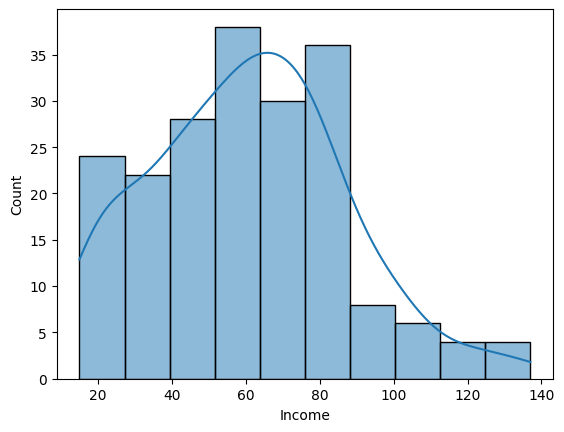

In [60]:
sns.histplot(df.Income, kde=True)

<Axes: xlabel='score', ylabel='Income'>

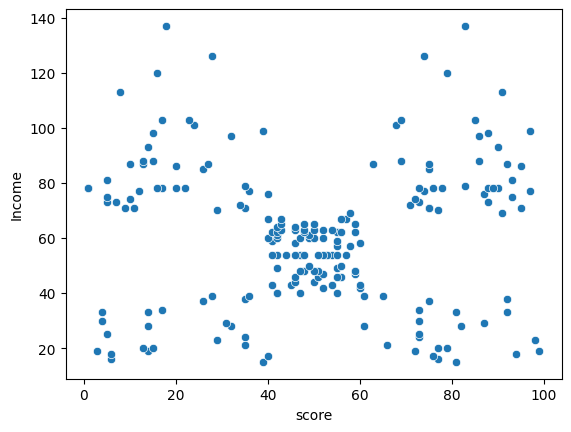

In [61]:
sns.scatterplot(y= df.Income, x= df.score)

In [62]:
X= df[['Income', 'score']].values

In [63]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [64]:
km5 = KMeans(n_clusters= 5, init='k-means++', random_state=0)
y_pred = km5.fit_predict(X_scaled)

In [65]:
km5 = KMeans(n_clusters= 5, init='k-means++', random_state=0)
km5.fit(X_scaled)

KMeans(n_clusters=5, random_state=0)

In [66]:
(y_pred == km5.labels_).all()

np.True_

In [67]:
km5.inertia_

65.56840815571681

In [68]:
km5 = KMeans(n_clusters= 5, init='k-means++', random_state=11)
km5.fit(X_scaled)
km5.score(X_scaled)

-65.57885579985047

In [54]:
X[y_pred == 0,1]

array([61, 55, 47, 42, 42, 52, 60, 54, 60, 45, 41, 50, 46, 51, 46, 56, 55,
       52, 59, 51, 59, 50, 48, 59, 47, 55, 42, 49, 56, 47, 54, 53, 48, 52,
       42, 51, 55, 41, 44, 57, 46, 58, 55, 60, 46, 55, 41, 49, 40, 42, 52,
       47, 50, 42, 49, 41, 48, 59, 55, 56, 42, 50, 46, 43, 48, 52, 54, 42,
       46, 48, 50, 43, 59, 43, 57, 56, 40, 58, 35, 34, 40])

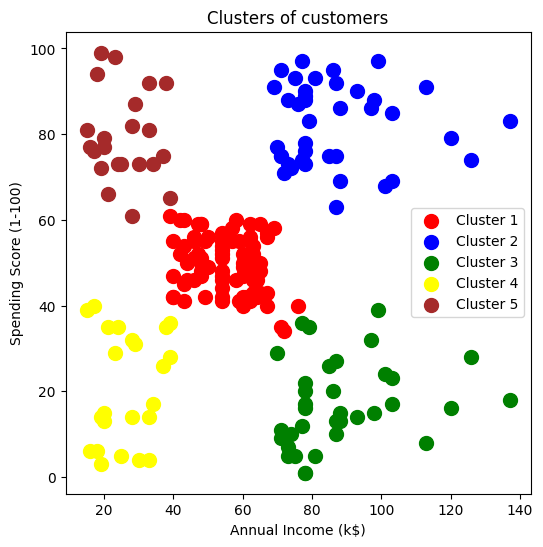

In [53]:
#Visualizing all the clusters 
plt.figure(figsize=(6,6))
plt.scatter(X[y_pred == 0, 0], X[y_pred == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_pred == 1, 0], X[y_pred == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_pred == 2, 0], X[y_pred == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_pred == 3, 0], X[y_pred == 3, 1], s = 100, c = 'yellow', label = 'Cluster 4')
plt.scatter(X[y_pred == 4, 0], X[y_pred == 4, 1], s = 100, c = 'brown', label = 'Cluster 5')

plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()